In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
with open('output.pkl', 'rb') as f:
    data = pickle.load(f)

print(data.keys())

dict_keys(['split', 'annotations'])


In [3]:
split = data.get('split', {})
for k, v in split.items():
    print(f"{k}: {v}")

train: []
val: [0]


In [4]:
annot = data['annotations'][0]

for k,v in annot.items():
    if isinstance(v, (list, np.ndarray)):
        print(f"  {k}: type={type(v)}, shape={np.shape(v)}")
    else:
        print(f"  {k}: {v}")

  start_frame: 0
  end_frame: 12686
  frame_dir: video
  total_frames: 12687
  img_shape: type=<class 'list'>, shape=(2,)
  original_shape: type=<class 'list'>, shape=(2,)
  pos_label: Unknown
  source: custom_prediction
  label: 0
  keypoint: type=<class 'numpy.ndarray'>, shape=(1, 12687, 17, 2)
  keypoint_score: type=<class 'numpy.ndarray'>, shape=(1, 12687, 17)


In [5]:
data['split']['val'] = ['video']

with open('output.pkl', 'wb') as f:
    pickle.dump(data, f)

In [6]:
with open('output.pkl', 'rb') as f:
    new_data = pickle.load(f)
print(new_data['split']['val'])

['video']


In [7]:
def get_layout(layout: str) -> None:
    """Initialize the layout of candidates."""

    if layout == 'openpose':
        num_node = 18
        inward = [(4, 3), (3, 2), (7, 6), (6, 5), (13, 12), (12, 11),
                        (10, 9), (9, 8), (11, 5), (8, 2), (5, 1), (2, 1),
                        (0, 1), (15, 0), (14, 0), (17, 15), (16, 14)]
        center = 1
    elif layout == 'human3.6m':
        num_node = 17
        inward = [(10, 9), (9, 8), (8,7), (7,0), (13, 12), (12, 11), (11, 8),
                  (16, 15), (15, 14), (14, 8),
                  (13, 12), (12, 11), (11, 8),
                  (3, 2), (2,1), (1,0),
                  (6,5), (5,4), (4,0)]
        center = 0
    elif layout == 'nturgb+d':
        num_node = 25
        neighbor_base = [(1, 2), (2, 21), (3, 21), (4, 3), (5, 21), (6, 5),
                            (7, 6), (8, 7), (9, 21), (10, 9), (11, 10),
                            (12, 11), (13, 1), (14, 13), (15, 14), (16, 15),
                            (17, 1), (18, 17), (19, 18), (20, 19), (22, 8),
                            (23, 8), (24, 12), (25, 12)]
        inward = [(i - 1, j - 1) for (i, j) in neighbor_base]
        center = 21 - 1
    elif layout == 'coco':
        num_node = 17
        inward = [(15, 13), (13, 11), (16, 14), (14, 12), (11, 5),
                        (12, 6), (9, 7), (7, 5), (10, 8), (8, 6), (5, 0),
                        (6, 0), (1, 0), (3, 1), (2, 0), (4, 2)]
        center = 0
    elif isinstance(layout, dict):
        num_node = layout['num_node']
        inward = layout['inward']
        center = layout['center']
    else:
        raise ValueError(f'Do Not Exist This Layout: {layout}')
    return num_node, inward, center

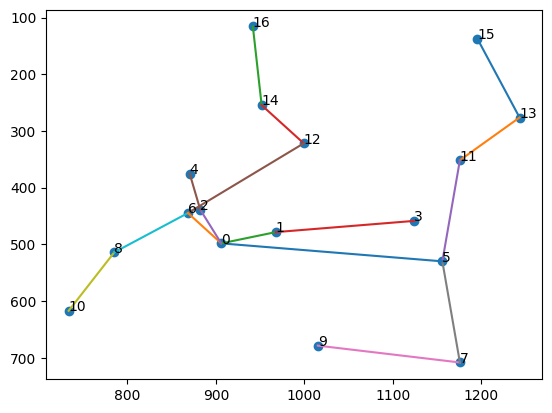

In [8]:
t = 0
sample_2d = new_data['annotations'][0]['keypoint'][0, t]
num_nodes, inward, center = get_layout('coco')
assert sample_2d.shape[0] == num_nodes
Xs = sample_2d[:,0]
Ys = sample_2d[:,1]
fig, ax = plt.subplots()
ax.invert_yaxis()
ax.scatter(Xs, Ys)
for i, joint in enumerate(sample_2d):
    ax.annotate(xy=joint, text=i)
for bone in inward:
    ax.plot((Xs[bone[0]], Xs[bone[1]]), (Ys[bone[0]], Ys[bone[1]]))

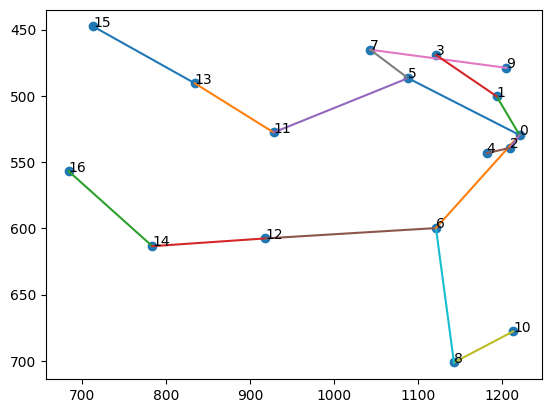

In [9]:
t = 1000
sample_2d = new_data['annotations'][0]['keypoint'][0, t]
num_nodes, inward, center = get_layout('coco')
assert sample_2d.shape[0] == num_nodes
Xs = sample_2d[:,0]
Ys = sample_2d[:,1]
fig, ax = plt.subplots()
ax.invert_yaxis()
ax.scatter(Xs, Ys)
for i, joint in enumerate(sample_2d):
    ax.annotate(xy=joint, text=i)
for bone in inward:
    ax.plot((Xs[bone[0]], Xs[bone[1]]), (Ys[bone[0]], Ys[bone[1]]))